# Análise corrigida: PETR4 vs WTI

Esta versão apresenta apenas a análise metodologicamente correta. A primeira abordagem exploratória foi removida para evitar confundir a interpretação.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR

In [2]:
prices = pd.read_csv("DATA_SET/Global_Commodity_Prices_2000_2026.csv")
oil_prices = prices.loc[prices["Commodity"] == "Crude Oil WTI", ["Date", "Close"]].copy()
oil_prices["Date"] = pd.to_datetime(oil_prices["Date"])
oil_prices = oil_prices.sort_values("Date").reset_index(drop=True)
oil_prices.head()

,Date,Close
0,2000-08-23,32.049999
1,2000-08-24,31.629999
2,2000-08-25,32.049999
3,2000-08-28,32.869999
4,2000-08-29,32.720001


In [4]:
petr4 = pd.read_csv("DATA_SET/Petrobras Historical Stock Data (2000-2026).csv")
petr4 = petr4[["Date", "Close", "Open"]].copy()
petr4["Date"] = pd.to_datetime(petr4["Date"], errors="coerce")
petr4 = petr4.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
petr4.head()

,Date,Close,Open
0,2000-08-10,1.254158,1.106288
1,2000-08-11,1.251420,1.199391
2,2000-08-14,1.245943,1.232251
3,2000-08-15,1.251420,1.245943
4,2000-08-16,1.284280,1.262373


In [5]:
merged = pd.merge(
    petr4[["Date", "Close"]].rename(columns={"Close": "PETR4"}),
    oil_prices.rename(columns={"Close": "WTI"}),
    on="Date",
    how="inner"
).dropna().reset_index(drop=True)

print(f"Linhas após merge por data: {len(merged)}")
merged.head()

Linhas após merge por data: 6406


,Date,PETR4,WTI
0,2000-08-23,1.319878,32.049999
1,2000-08-24,1.292495,31.629999
2,2000-08-25,1.325354,32.049999
3,2000-08-28,1.319878,32.869999
4,2000-08-29,1.363692,32.720001


In [6]:
merged["PETR4_norm"] = merged["PETR4"] / merged["PETR4"].max()
merged["WTI_norm"] = merged["WTI"] / merged["WTI"].max()
merged["DIF"] = (merged["PETR4_norm"] - merged["WTI_norm"]).abs()

top_dif = merged.sort_values("DIF", ascending=False).head(10)
top_dif

,Date,PETR4,WTI,PETR4_norm,WTI_norm,DIF
5403,2022-03-08,5.143801,123.699997,0.281619,0.851401,0.569781
3386,2014-03-03,3.135011,104.919998,0.171640,0.722142,0.550502
5402,2022-03-07,5.012486,119.400002,0.274430,0.821805,0.547375
3224,2013-07-10,3.518656,106.519997,0.192644,0.733154,0.540510
3259,2013-08-28,3.996781,110.099998,0.218821,0.757795,0.538974
3387,2014-03-04,3.175093,103.330002,0.173834,0.711198,0.537364
3378,2014-02-19,3.186546,103.309998,0.174461,0.711061,0.536600
3390,2014-03-07,3.120695,102.580002,0.170856,0.706036,0.535180
3260,2013-08-29,3.916617,108.800003,0.214432,0.748847,0.534415
3262,2013-09-03,3.893712,108.540001,0.213178,0.747058,0.533880


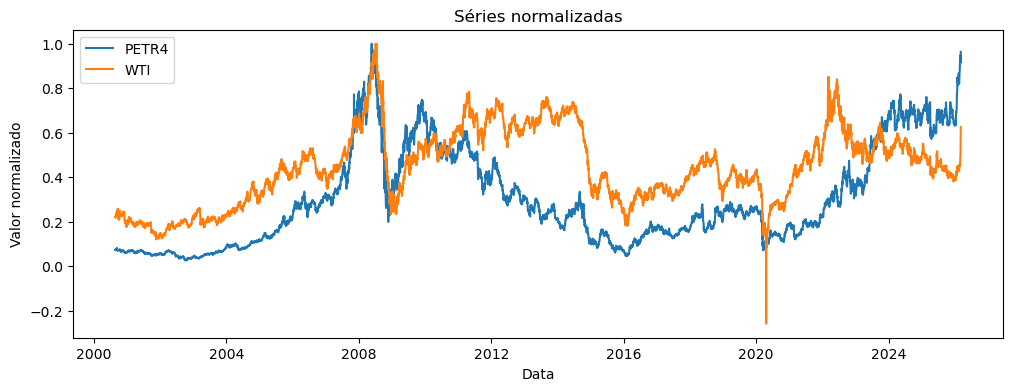

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(merged["Date"], merged["PETR4_norm"], label="PETR4")
plt.plot(merged["Date"], merged["WTI_norm"], label="WTI")
plt.title("Séries normalizadas")
plt.xlabel("Data")
plt.ylabel("Valor normalizado")
plt.legend()
plt.show()

In [8]:
merged["PETR4_ret"] = merged["PETR4"].pct_change()
merged["WTI_ret"] = merged["WTI"].pct_change()
returns = merged.dropna(subset=["PETR4_ret", "WTI_ret"]).reset_index(drop=True)
returns[["Date", "PETR4_ret", "WTI_ret"]].head()

,Date,PETR4_ret,WTI_ret
0,2000-08-24,-0.020747,-0.013105
1,2000-08-25,0.025424,0.013279
2,2000-08-28,-0.004132,0.025585
3,2000-08-29,0.033196,-0.004563
4,2000-08-30,0.036144,0.020782


In [9]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- {name} ---")
    print(f"Estatística ADF: {result[0]:.4f}")
    print(f"p-valor: {result[1]:.4f}")
    print(f"Estacionária a 5%? {'SIM' if result[1] < 0.05 else 'NÃO'}")
    print()

adf_report(merged["PETR4_norm"], "PETR4 normalizado (nível)")
adf_report(merged["WTI_norm"], "WTI normalizado (nível)")
adf_report(returns["PETR4_ret"], "PETR4 (retornos)")
adf_report(returns["WTI_ret"], "WTI (retornos)")

--- PETR4 normalizado (nível) ---
Estatística ADF: -0.9019
p-valor: 0.7873
Estacionária a 5%? NÃO

--- WTI normalizado (nível) ---
Estatística ADF: -2.8783
p-valor: 0.0479
Estacionária a 5%? SIM

--- PETR4 (retornos) ---
Estatística ADF: -19.1578
p-valor: 0.0000
Estacionária a 5%? SIM

--- WTI (retornos) ---
Estatística ADF: -14.7759
p-valor: 0.0000
Estacionária a 5%? SIM



In [10]:
var_input = returns[["WTI_ret", "PETR4_ret"]]
lag_order = VAR(var_input).select_order(maxlags=30)
print(lag_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -13.02      -13.01   2.226e-06      -13.01
1       -13.08      -13.07   2.090e-06      -13.08
2       -13.11     -13.10*   2.033e-06      -13.10
3       -13.11      -13.09   2.031e-06      -13.10
4       -13.11      -13.09   2.030e-06      -13.10
5       -13.11      -13.09   2.022e-06      -13.10
6       -13.11      -13.08   2.023e-06      -13.10
7       -13.11      -13.08   2.017e-06      -13.10
8       -13.11      -13.08   2.017e-06      -13.10
9       -13.11      -13.07   2.018e-06      -13.10
10      -13.12      -13.07   2.010e-06      -13.10
11      -13.12      -13.07   2.001e-06      -13.11
12      -13.12      -13.07   2.000e-06      -13.10
13      -13.12      -13.06   2.001e-06      -13.10
14      -13.12      -13.06   2.001e-06      -13.10
15      -13.12      -13.06   2.000e-06      -13.10
16      -13.12      -13.05   1.

In [11]:
LAGS = 5

print("=" * 60)
print("H0: WTI NÃO causa PETR4")
print("=" * 60)
grangercausalitytests(returns[["PETR4_ret", "WTI_ret"]], LAGS)

print("=" * 60)
print("H0: PETR4 NÃO causa WTI")
print("=" * 60)
grangercausalitytests(returns[["WTI_ret", "PETR4_ret"]], LAGS)

H0: WTI NÃO causa PETR4

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3323  , p=0.5643  , df_denom=6401, df_num=1
ssr based chi2 test:   chi2=0.3324  , p=0.5642  , df=1
likelihood ratio test: chi2=0.3324  , p=0.5642  , df=1
parameter F test:         F=0.3323  , p=0.5643  , df_denom=6401, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1910  , p=0.8261  , df_denom=6398, df_num=2
ssr based chi2 test:   chi2=0.3823  , p=0.8260  , df=2
likelihood ratio test: chi2=0.3823  , p=0.8260  , df=2
parameter F test:         F=0.1910  , p=0.8261  , df_denom=6398, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.8886  , p=0.1292  , df_denom=6395, df_num=3
ssr based chi2 test:   chi2=5.6719  , p=0.1287  , df=3
likelihood ratio test: chi2=5.6694  , p=0.1289  , df=3
parameter F test:         F=1.8886  , p=0.1292  , df_denom=6395, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test: 

{np.int64(1): ({'ssr_ftest': (np.float64(13.607053883109128),
    np.float64(0.0002272059382611159),
    np.float64(6401.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(13.613431193162143),
    np.float64(0.00022457306863286856),
    np.int64(1)),
   'lrtest': (np.float64(13.598982154486293),
    np.float64(0.00022630819595006782),
    np.int64(1)),
   'params_ftest': (np.float64(13.607053883108566),
    np.float64(0.00022720593826118816),
    np.float64(6401.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(13.139964172460205),
    np.float64(2.0187107458332705e-06),
    np.float64(6398.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(26.300465956943636),
    np.float64(1.9450303469476213e-06),
    np.int64(2)),
   'lrtest': (np.float64(26.246598537734826),
    np.float64(1.9981290926934786e-06),
    np.int64(2)),
   'params_ftest': (np.float64(13.13996417246414),
    np.float64(2.018710745825582e-06),
    np.float64(6398.0),
    2.0)},
   ar

A análise acima mostra a versão corrigida do fluxo: merge por data, normalização, diferença entre séries, retornos, teste ADF e teste de Granger. A interpretação deve ser cautelosa, pois os resultados não sustentam uma causalidade demonstrada de forma robusta.